In [1]:
import h5py
import numpy as np
import lib.dls_2d as dls 
import matplotlib.pyplot as plt
import importlib

In [2]:
with h5py.File('data/ldc_15k.h5', 'r') as f:
    input_dict = {
        'UV': f['UV'][:10],
        'mean': f['mean'][:],
        'x_grid': f['x_grid'][:].T,
        'y_grid': f['y_grid'][:].T
    }


In [7]:
latent_config, dof_u, dof_v = dls.gfem_compress_flexible(data_source=input_dict,
                           field_name='UV',
                           patch_size=99,
                           num_modes=50)

100%|██████████| 1/1 [00:00<00:00,  2.36it/s]


In [8]:
Q_rec = dls.gfem_recon_flexible(config=latent_config, dof_u=dof_u, dof_v=dof_v, rec_target=None)

Relative error: 0.6264%


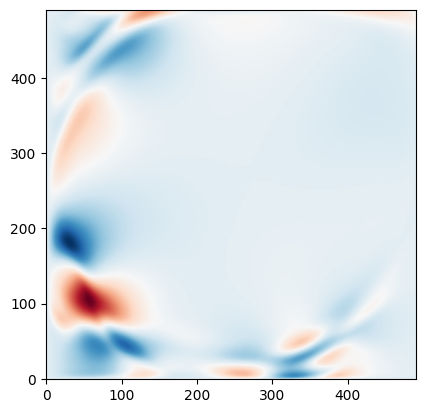

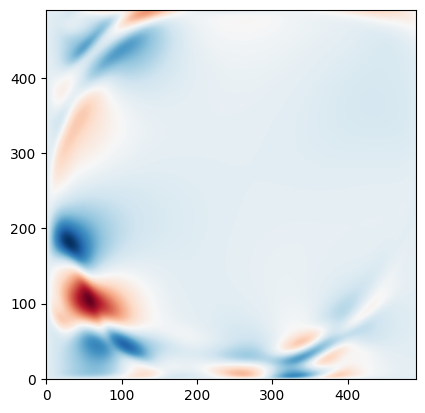

In [9]:
Q_true = input_dict['UV'][:, :, :] - input_dict['mean'][None, :]
Q_true = Q_true[:, :latent_config.nx_t, :latent_config.ny_t]

error = np.linalg.norm(Q_true - Q_rec) / np.linalg.norm(Q_true)
print(f"Relative error: {100*error:.4f}%")

plt.imshow(Q_rec[-1, :, :, 0], origin='lower', cmap='RdBu_r')
plt.show()

plt.figure()
plt.imshow(Q_true[-1, :, :, 0], origin='lower', cmap='RdBu_r')
plt.show()

In [6]:
# lltogl_mat = None
# u_sel = dof_u[:, lltogl_mat]
# v_sel = dof_v[:, lltogl_mat]
# dof_input = np.transpose(np.concatenate([u_sel, v_sel], axis=2), (1, 0, 2))

# num_dofs = dof_input.shape[-1] // 2


# dof_u = dof_input[:, :, :num_dofs].squeeze()
# dof_v = dof_input[:, :, num_dofs:2 * num_dofs].squeeze()